# Q3: Pathway-Signaling ODE Model of Anti-EGFR Response in CRC

In [2]:
## Import data

import pandas as pd
df = pd.read_csv("../data/raw/sourcedata_fig4a_fig5.csv")
# print(df.columns.tolist())
# print(df.head())

egfr = df[df['Unnamed: 0'] == 'P00533']

# pick one cell line, e.g. HCT
cols = [c for c in df.columns if c.startswith('HCT_OS_')]
timepoints = ['5min','15min','1h','6h','24h','48h','96h']
cols_ordered = [f'HCT_OS_{t}' for t in timepoints]

egfr_trace = egfr[cols_ordered].values.flatten()
print(dict(zip(timepoints, egfr_trace)))

{'5min': np.float64(-0.389967578597161), '15min': np.float64(-0.22426134764253), '1h': np.float64(-0.773984814897985), '6h': np.float64(-0.811480509019251), '24h': np.float64(-0.862828058628247), '48h': np.float64(0.587360392101448), '96h': np.float64(0.943444817681168)}


In [3]:
import numpy as np

hours = {'5min': 5/60, '15min': 15/60, '1h': 1, '6h': 6, '24h': 24, '48h': 48, '96h': 96}
t = np.array(list(hours.values()))

os_trace = egfr[[f'HCT_OS_{k}' for k in hours]].values.flatten()
control_trace = egfr[[f'HCT_C_{k}' for k in hours]].values.flatten()

drug_effect = os_trace - control_trace   # isolates the drug's effect from baseline noise
print(dict(zip(hours.keys(), drug_effect)))

{'5min': np.float64(-0.3474820036601207), '15min': np.float64(-0.591180241516746), '1h': np.float64(-0.332022564736207), '6h': np.float64(-1.321592463171893), '24h': np.float64(-1.489979878168116), '48h': np.float64(1.282081538573443), '96h': np.float64(0.2692536002023229)}


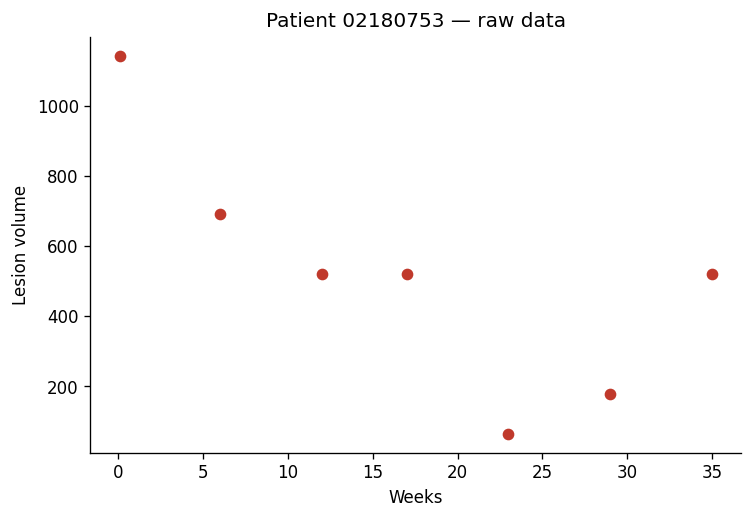

r=3.5963, k=3.7011, k_elim=0.0012


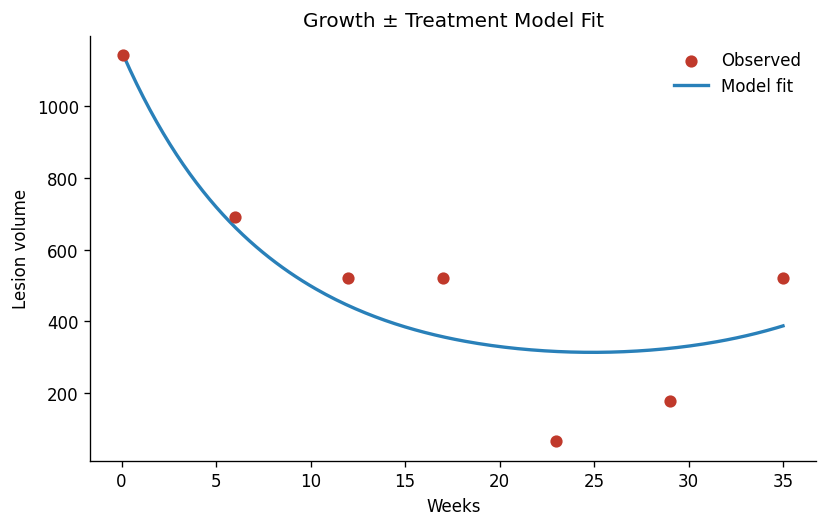

In [4]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 1. Load & pick one patient ---
df = pd.read_csv("../data/raw/flat_patient_data.csv")

patient_id = df["Pt_hashID"].iloc[0]          # swap for any patient hash
pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")

data_time = pt["T_weeks"].values
data_volume = pt["Lesion_vol"].values

# --- 2. Plot raw data ---
fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.scatter(data_time, data_volume, color='#c0392b', label='Observed')
ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
ax.set_title(f'Patient {patient_id[:8]} — raw data')
ax.spines[['top','right']].set_visible(False)
plt.show()

# --- 3. ODE system ---
def growth_treatment(t, y, r, k, k_elim):
    T, C = y
    dTdt = r*T - k*C*T
    dCdt = -k_elim*C
    return [dTdt, dCdt]

def simulate(t_eval, r, k, k_elim, T0, C0=1.0):
    sol = solve_ivp(growth_treatment, [t_eval[0], t_eval[-1]], [T0, C0],
                     args=(r, k, k_elim), t_eval=t_eval, method='RK45')
    return sol.y[0]

def fit_func(t, r, k, k_elim):
    return simulate(t, r, k, k_elim, T0=data_volume[0])

# --- 4. Fit ---
popt, pcov = curve_fit(fit_func, data_time, data_volume,
                        p0=[0.05, 0.05, 0.05], bounds=(0, np.inf), maxfev=10000)
r_fit, k_fit, k_elim_fit = popt
print(f"r={r_fit:.4f}, k={k_fit:.4f}, k_elim={k_elim_fit:.4f}")

# --- 5. Plot fit vs data ---
t_smooth = np.linspace(data_time.min(), data_time.max(), 200)
fitted_smooth = simulate(t_smooth, r_fit, k_fit, k_elim_fit, T0=data_volume[0])

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.scatter(data_time, data_volume, color='#c0392b', label='Observed', zorder=3, s=40)
ax.plot(t_smooth, fitted_smooth, color='#2980b9', label='Model fit', linewidth=2)
ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
ax.set_title('Growth ± Treatment Model Fit')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/model1_fit.png', dpi=150)
plt.show()

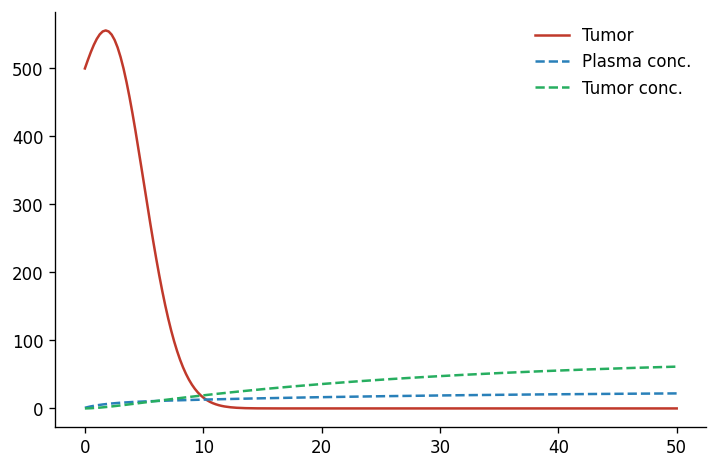

In [5]:
def pk_infiltration(t, y, k12, k21, k_elim, dose_rate):
    T, C_plasma, C_tumor = y
    dTdt = 0.1*T - 0.05*C_tumor*T
    dCp = dose_rate - k_elim*C_plasma - k12*C_plasma + k21*C_tumor
    dCt = k12*C_plasma - k21*C_tumor
    return [dTdt, dCp, dCt]

sol = solve_ivp(pk_infiltration, [0, 50], [500, 1, 0],
                 args=(0.3, 0.1, 0.2, 5), t_eval=np.linspace(0, 50, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.plot(sol.t, sol.y[0], label='Tumor', color='#c0392b')
ax.plot(sol.t, sol.y[1], label='Plasma conc.', color='#2980b9', linestyle='--')
ax.plot(sol.t, sol.y[2], label='Tumor conc.', color='#27ae60', linestyle='--')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.savefig('../outputs/pkInfiltration', dpi=150)
plt.show()

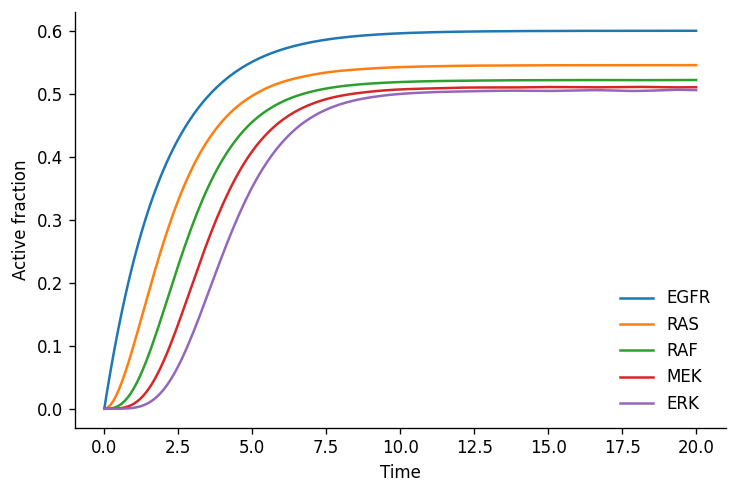

In [6]:
# --- Model 3: Pathway inhibition ---
def pathway(t, y, I=0.7):
    EGFR, RAS, RAF, MEK, ERK = y
    k, d = 1.0, 0.5
    dEGFR = k*(1-I) - d*EGFR
    dRAS  = k*EGFR*(1-RAS) - d*RAS
    dRAF  = k*RAS*(1-RAF) - d*RAF
    dMEK  = k*RAF*(1-MEK) - d*MEK
    dERK  = k*MEK*(1-ERK) - d*ERK
    return [dEGFR, dRAS, dRAF, dMEK, dERK]

sol3 = solve_ivp(pathway, [0, 20], [0,0,0,0,0], t_eval=np.linspace(0, 20, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
for i, name in enumerate(['EGFR','RAS','RAF','MEK','ERK']):
    ax.plot(sol3.t, sol3.y[i], label=name)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_xlabel('Time'); ax.set_ylabel('Active fraction')
plt.savefig('../outputs/PathwayInbibition', dpi=150)
plt.show()

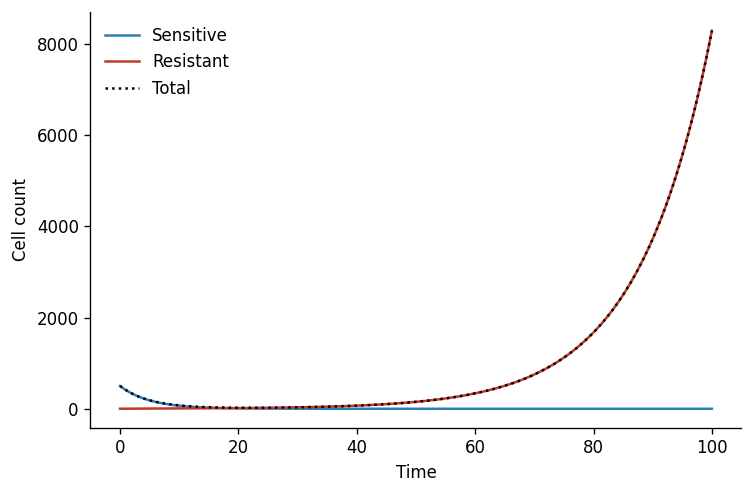

In [7]:
# --- Model 4: Resistance emergence ---
def resistance(t, y, r_s=0.1, r_r=0.08, k=0.3, mu=0.001):
    S, R = y
    dS = r_s*S - k*S - mu*S
    dR = r_r*R + mu*S
    return [dS, dR]

sol4 = solve_ivp(resistance, [0, 100], [500, 1], t_eval=np.linspace(0, 100, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.plot(sol4.t, sol4.y[0], label='Sensitive', color='#2980b9')
ax.plot(sol4.t, sol4.y[1], label='Resistant', color='#c0392b')
ax.plot(sol4.t, sol4.y[0]+sol4.y[1], label='Total', color='black', linestyle=':')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_xlabel('Time'); ax.set_ylabel('Cell count')
plt.savefig('../outputs/ResistanceEmergence', dpi=150)
plt.show()

In [10]:
# --- Reusable per-patient fit function (robust version) ---
def simulate_stable(t_eval, r, k, k_elim, T0, C0=1.0):
    sol = solve_ivp(growth_treatment, [t_eval[0], t_eval[-1]], [T0, C0],
                     args=(r, k, k_elim), t_eval=t_eval, method='LSODA', max_step=5)
    if not sol.success:
        raise RuntimeError("integration failed")
    return sol.y[0]

def fit_patient(patient_id, df):
    pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")
    pt = pt.dropna(subset=["T_weeks", "Lesion_vol"]).drop_duplicates(subset="T_weeks")
    t, v = pt["T_weeks"].values, pt["Lesion_vol"].values
    if len(t) < 4:
        return None
    def fit_func(t, r, k, k_elim):
        return simulate_stable(t, r, k, k_elim, T0=v[0])
    try:
        popt, _ = curve_fit(fit_func, t, v, p0=[0.05, 0.05, 0.05],
                             bounds=(0, np.inf), maxfev=1500)
        pred = fit_func(t, *popt)
        ss_res = np.sum((v - pred)**2); ss_tot = np.sum((v - np.mean(v))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return {"patient": patient_id, "r": popt[0], "k": popt[1], "k_elim": popt[2],
                "n_points": len(t), "r2": r2, "study_arm": pt['Study_Arm'].iloc[0]}
    except Exception:
        return None

patients = df["Pt_hashID"].unique()
print(f"{len(patients)} patients")

results = []
for i, pid in enumerate(patients):
    res = fit_patient(pid, df)
    if res:
        results.append(res)
    if i % 200 == 0:
        print(f"  {i}/{len(patients)}")

results_df = pd.DataFrame(results)
results_df.to_csv('../results/per_patient_fits.csv', index=False)
print(f"Fitted {len(results_df)}/{len(patients)} patients")
results_df.describe()

Fitted 1021/1461 patients


,r,k,k_elim,n_points,r2
count,1.021000e+03,1.021000e+03,1.021000e+03,1021.000000,9.960000e+02
mean,3.959418e+00,4.182337e+00,1.672304e-01,6.809990,-3.479586e+03
std,1.288756e+01,1.286611e+01,4.944084e-01,2.593948,1.098364e+05
min,4.940656e-324,2.092915e-33,1.180309e-34,4.000000,-3.466377e+06
25%,1.794605e-03,2.188246e-02,1.548010e-08,5.000000,6.615498e-01
50%,2.991733e-02,1.747583e-01,1.986482e-04,6.000000,8.900824e-01
75%,2.750849e-01,7.650417e-01,8.072624e-02,9.000000,9.830508e-01
max,1.249025e+02,1.250497e+02,3.655209e+00,16.000000,1.000000e+00


In [11]:
# import os
# os.makedirs('../results', exist_ok=True)
# os.makedirs('../outputs', exist_ok=True)

In [12]:
for min_pts in [4,5,6,7,8]:
    sub = results_df[results_df['n_points']>=min_pts]
    print(f"n_points>={min_pts}: n={len(sub)}, median R2={sub['r2'].median():.3f}, "
          f"R2<0 count={(sub['r2']<0).sum()} ({100*(sub['r2']<0).mean():.1f}%)")

n_points>=4: n=1021, median R2=0.890, R2<0 count=74 (7.2%)
n_points>=5: n=791, median R2=0.885, R2<0 count=54 (6.8%)
n_points>=6: n=619, median R2=0.873, R2<0 count=46 (7.4%)
n_points>=7: n=461, median R2=0.870, R2<0 count=33 (7.2%)
n_points>=8: n=348, median R2=0.873, R2<0 count=24 (6.9%)


In [13]:
def loo_check(patient_id, df):
    pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")
    pt = pt.dropna(subset=["T_weeks","Lesion_vol"]).drop_duplicates(subset="T_weeks")
    t, v = pt["T_weeks"].values, pt["Lesion_vol"].values
    if len(t) < 6:
        return None
    errors = []
    for hold_idx in range(len(t)):
        t_train = np.delete(t, hold_idx); v_train = np.delete(v, hold_idx)
        try:
            def fit_func(t, r, k, k_elim):
                return simulate_stable(t, r, k, k_elim, T0=v_train[0])
            popt, _ = curve_fit(fit_func, t_train, v_train, p0=[0.05,0.05,0.05],
                                 bounds=(0,np.inf), maxfev=1200)
            t_span = [min(t_train[0], t[hold_idx]), max(t_train[-1], t[hold_idx])]
            sol = solve_ivp(growth_treatment, t_span, [v_train[0], 1.0], args=tuple(popt),
                             t_eval=sorted(set(list(t_train)+[t[hold_idx]])),
                             method='LSODA', max_step=5)
            idx = list(sol.t).index(t[hold_idx])
            pred_held = sol.y[0][idx]
            errors.append(abs(pred_held - v[hold_idx]) / (v[hold_idx]+1e-6))
        except Exception:
            continue
    if not errors:
        return None
    return {"patient": patient_id, "mean_pct_error": np.mean(errors)*100, "n_points": len(t)}

candidates = [pid for pid in patients if df[df['Pt_hashID']==pid]['T_weeks'].nunique() >= 6][:50]
loo_results = [r for pid in candidates if (r := loo_check(pid, df))]
loo_df = pd.DataFrame(loo_results)
loo_df.to_csv('../results/loo_validation.csv', index=False)
print(f"LOO done on {len(loo_df)} patients, median error: {loo_df['mean_pct_error'].median():.1f}%")

LOO done on 50 patients, median error: 36.7%


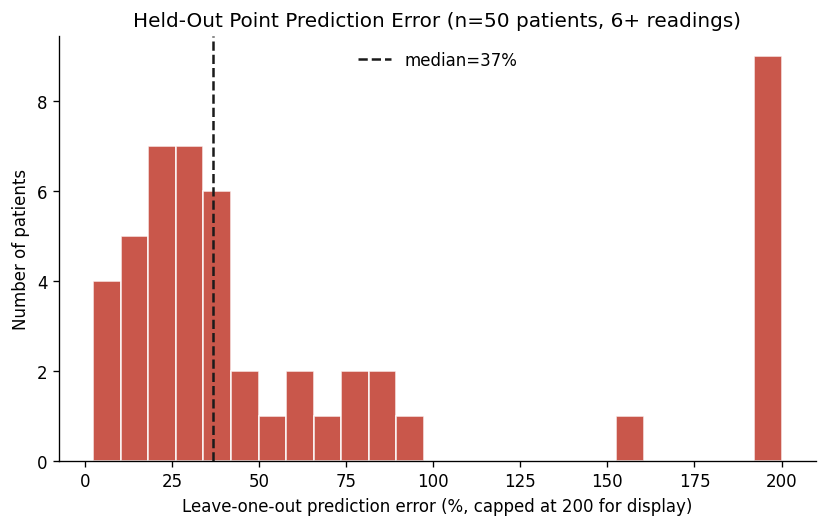

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
capped = loo_df['mean_pct_error'].clip(upper=200)
ax.hist(capped, bins=25, color='#c0392b', edgecolor='white', alpha=0.85)
ax.axvline(loo_df['mean_pct_error'].median(), color='#1a1a1a', linestyle='--',
           label=f"median={loo_df['mean_pct_error'].median():.0f}%")
ax.set_xlabel('Leave-one-out prediction error (%, capped at 200 for display)')
ax.set_ylabel('Number of patients')
ax.set_title(f'Held-Out Point Prediction Error (n={len(loo_df)} patients, 6+ readings)')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/loo_validation.png', dpi=150)
plt.show()

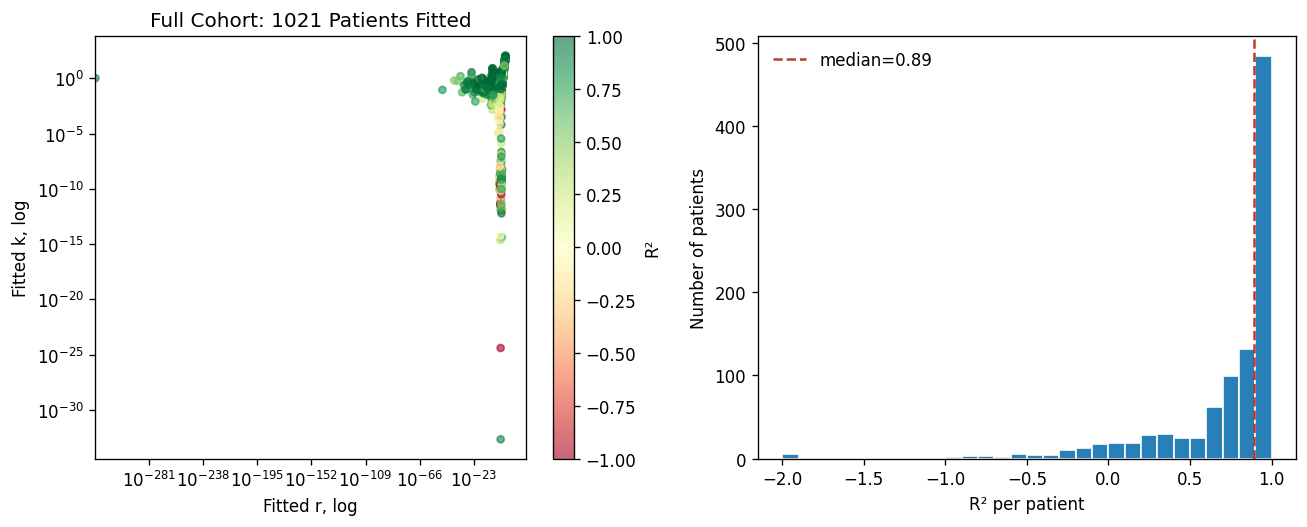

In [14]:
clean = results_df[(results_df['r']>0) & (results_df['k']>0)]
fig, axes = plt.subplots(1, 2, figsize=(11,4.5), dpi=120)
sc = axes[0].scatter(clean['r'], clean['k'], c=clean['r2'].clip(-1,1), cmap='RdYlGn', vmin=-1, vmax=1, s=18, alpha=0.6)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Fitted r, log'); axes[0].set_ylabel('Fitted k, log')
axes[0].set_title(f'Full Cohort: {len(clean)} Patients Fitted')
plt.colorbar(sc, ax=axes[0], label='R²')

axes[1].hist(results_df['r2'].clip(-2,1), bins=30, color='#2980b9', edgecolor='white')
axes[1].axvline(results_df['r2'].median(), color='#c0392b', linestyle='--', label=f"median={results_df['r2'].median():.2f}")
axes[1].set_xlabel('R² per patient'); axes[1].set_ylabel('Number of patients')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.savefig('../outputs/full_cohort_accuracy.png', dpi=150)
plt.show()

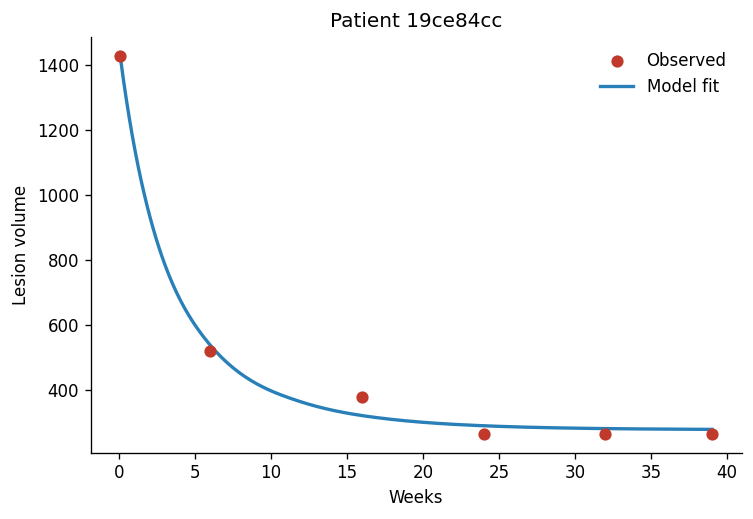

In [16]:
# --- Plot any patient by hash or index ---
def plot_patient(patient_id, df, results_df):
    pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")
    t, v = pt["T_weeks"].values, pt["Lesion_vol"].values
    row = results_df[results_df["patient"] == patient_id].iloc[0]

    t_smooth = np.linspace(t.min(), t.max(), 200)
    fitted = simulate(t_smooth, row["r"], row["k"], row["k_elim"], T0=v[0])

    fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
    ax.scatter(t, v, color='#c0392b', label='Observed', zorder=3, s=40)
    ax.plot(t_smooth, fitted, color='#2980b9', label='Model fit', linewidth=2)
    ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
    ax.set_title(f'Patient {patient_id[:8]}')
    ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
    plt.show()

# plot_patient(patients[0], df, results_df)
plot_patient(results_df['patient'].iloc[0], df, results_df)